In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Observation names are not unique. To make them unique, call `.obs_names_make_unique`."
)
warnings.filterwarnings(
    "ignore",
    message= "RuntimeWarning: invalid value encountered in divide"
)


In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
import yaml
import scvi
import pickle

In [5]:
control_key = "is_control"
condition_keys = "perturbation"
condition_combined_keys = "condition_combined"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "plate_well"

data_origin = "Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_10000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [6]:
# load data
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 17578 × 2000
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cell_line_idx', 'dose_value_scaled', 'time_scaled', 'condition_combined'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cov_config', 'global_rulebook', 'hvg', 'log1p', 'normalized_m', 'pca', 'perturbation_embeddings'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'
AnnData object with n_obs × n_vars = 718049 × 2000
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cel

In [7]:
# load model
from src.training import FNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(config_load_path, 'r') as f:
    config = yaml.safe_load(f)
    print(f"load saved_config from {config_load_path}")


model = FNet(
    in_out_dim=config["in_out_dim"], 
    rulebook = adata_control.uns["global_rulebook"],
    hidden_dim_v=config["hidden_dim_v"], 
    n_hiddens_v=config["n_hiddens_v"], 
    hidden_dim_g=config["hidden_dim_g"], 
    n_hiddens_g=config["n_hiddens_g"], 
    condition_dim=config["condition_dim"], 
    con_embedding_dim=config["con_embedding_dim"], 
    hidden_dim_con=config["hidden_dim_con"], 
    time_dim=config["time_dim"], 
    time_embedding_dim=config["time_embedding_dim"], 
    hidden_dim_time=config["hidden_dim_time"], 
    bottle_dim=config["bottle_dim"], 
    cov_emb_dim=config.get("cov_emb_dim", 64), 
    dropout=config["dropout"], 
    activation=config["activation"]
)

checkpoint = torch.load(model_load_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

load saved_config from experiments/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/config.yaml


FNet(
  (t_encoder): TimeEncoder()
  (activation): SiLU()
  (condition_encoder): Sequential(
    (0): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): SiLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): SiLU()
    (5): Linear(in_features=512, out_features=256, bias=True)
  )
  (time_mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (cov_encoders): ModuleDict(
    (cell_line): Embedding(3, 64)
    (dose_value): Sequential(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
    (time): Sequential(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
  )
  (v_net): Velocity_GrowthNet(
   

训练步数: 9900
最后一步 Loss: 0.306601
最后一步 vLoss: 0.295235
最后一步 gLoss: 0.011366
最后一步 test_Loss: 0.559369
最后一步 test_vLoss: 0.239798
最后一步 test_gLoss: 0.319572


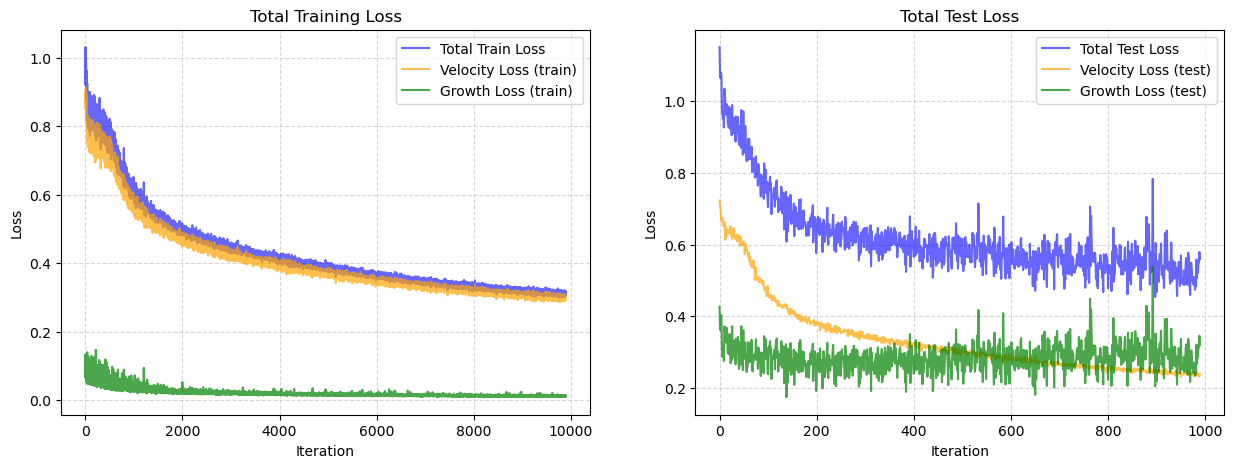

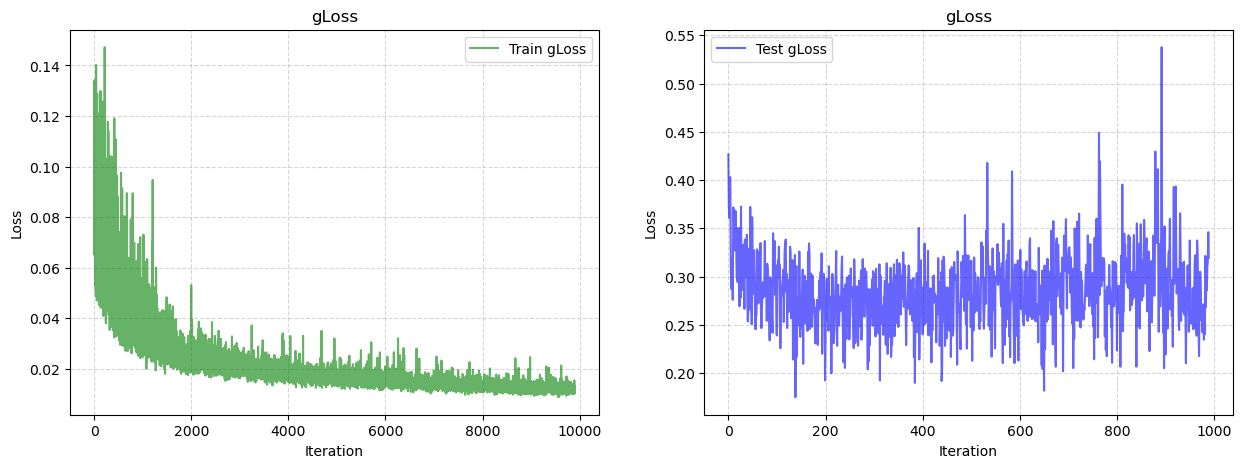

In [8]:
from src.evaluate import draw_loss
draw_loss(model_load_path,eval_interval = 10,cut = 100,save_path = results_save_path) # cut代表去掉前多少个epoch 避免前期loss过大影响观察

## inference & downstream

In [8]:
from src.evaluate.downstream import *
from src.evaluate.util import run_inference_and_reconstruct,evaluate_generated_results
from src.evaluate.evals_new import build_baseline_results

In [10]:
rulebook = adata_test.uns.get('global_rulebook')
if rulebook is None:
    raise ValueError("未找到 global_rulebook，请先确认数据经过了最新版 prepare_covariates 的处理！")

schema = rulebook["condition_tuple_schema"] 

# 我们直接从 adata_test 中，根据 schema 提取所有出现过的独立条件组合
# 然后直接转化为字典列表，这就是完美的 wishlist！
unique_conditions_df = adata_test.obs[schema].drop_duplicates()
wishlist = unique_conditions_df.to_dict(orient='records')

print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
print(f"示例: {wishlist[0]}") 

# base_condition_key 通常是 schema 的第一个元素（如 'perturbation'）
base_condition_key = schema[0] 

# rulebook = adata_train.uns.get('global_rulebook')
# schema = rulebook["condition_tuple_schema"] 
# unique_conditions_df = adata_train.obs[schema].drop_duplicates()
# wishlist = unique_conditions_df.to_dict(orient='records')
# print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
# print(f"示例: {wishlist[0]}") 
# base_condition_key = schema[0] 

成功从测试集中提取了 124 个评估愿望 (Wishlist)！
示例: {'perturbation': 'TAK-901', 'cell_line': 'MCF7', 'dose_value': 10000.0, 'time': 24.0}


In [11]:
wishlist = [ k for k in wishlist if k['perturbation']=='Belinostat (PXD101)' and k['time']==24 ]

In [12]:
len(wishlist)

12

In [12]:
from src.evaluate.util import run_inference_only
results_embedding, _, indices, reducer = run_inference_only(
    model=model,
    adata_control=adata_control,
    adata_test=adata_test,
    wishlist=wishlist,
    condition_keys=condition_keys,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device=device,
    n_particles=100000,
    n_steps=100,
    source_celltype_key="cell_line",
    return_traj=True,
    save_times = (0.0, 1.0),
    return_reducer=True,
    umap_n_neighbors = 30,
    umap_min_dist = 0.35,
    umap_random_state = 0,
    inference_modes=("all", "v_only", "g_only"),
)


Starting latent inference for 16 conditions...
Running inference for 16 conditions ...
Modes: ['all', 'v_only', 'g_only']


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Latent inference completed.


In [87]:
wishlist_1 = [ k for k in wishlist if k['dose_value']==10000  ]

In [88]:
wishlist_1 = [ k for k in wishlist_1 if k['time']==24  ]

In [89]:
wishlist_1

[{'perturbation': 'Belinostat (PXD101)',
  'cell_line': 'K562',
  'dose_value': 10000.0,
  'time': 24.0},
 {'perturbation': 'Belinostat (PXD101)',
  'cell_line': 'A549',
  'dose_value': 10000.0,
  'time': 24.0},
 {'perturbation': 'Belinostat (PXD101)',
  'cell_line': 'MCF7',
  'dose_value': 10000.0,
  'time': 24.0}]

## decouple v_net and g_net

In [50]:
from src.evaluate.wfr_multitime_umap_helper import fit_umap_reducer,plot_flow_inference_cellline_umap_grid_nm_style

/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


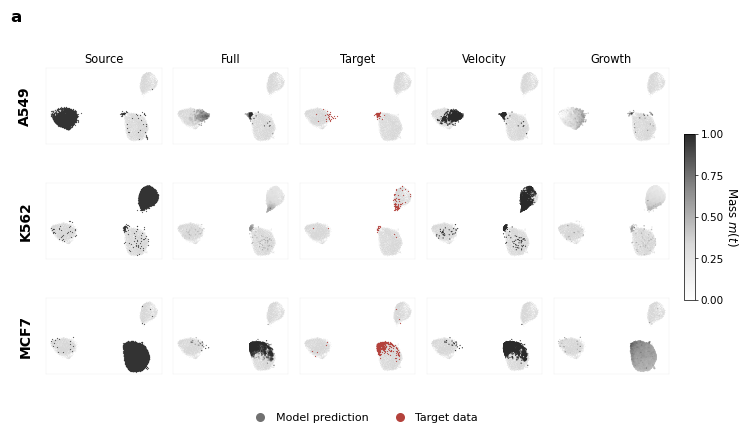

In [77]:
reducer = fit_umap_reducer(
    adata_source=adata_control,
    sample_rep=sample_rep,
    n_neighbors=30,
    min_dist=0.35,
    random_state=0,
)

row_specs = [
    {
        "wish": {
            "cell_line": "A549",
            "perturbation": "Belinostat (PXD101)",
            "dose_value": 10000.0,
            "time":24,
        },
        "row_label": "A549",
    },
    {
        "wish": {
            "cell_line": "K562",
            "perturbation": "Belinostat (PXD101)",
            "dose_value": 10000.0,
            "time":24,
        },
        "row_label": "K562",
    },
    {
        "wish": {
            "cell_line": "MCF7",
            "perturbation": "Belinostat (PXD101)",
            "dose_value": 10000.0,
            "time":24,
        },
        "row_label": "MCF7",
    },
]


from matplotlib.colors import LinearSegmentedColormap

mass_cmap_nm = LinearSegmentedColormap.from_list(
    "mass_nm",
    ["#FFFFFF", "#D9D9D9", "#8A8A8A", "#2A2A2A"]
)

fig, axes = plot_flow_inference_cellline_umap_grid_nm_style(
    results=results_embedding,
    row_specs=row_specs,
    adata_source=adata_control,
    adata_target=adata_test,
    reducer=reducer,
    sample_rep=sample_rep,

    source_inference_time=0.0,
    target_inference_time=1.0,

    background="all_source",
    adata_background=adata_control,

    mass_cmap=mass_cmap_nm,
    mass_transform="raw",
    mass_vmin=0.0,
    mass_vmax=1.0,
    prediction_alpha=0.92,
    sort_points_by_mass=True,

    source_color="#333333",
    source_alpha=0.78,
    source_point_size=0.8,

    observed_color="#B4423C",
    observed_alpha=0.90,

    point_size=0.8,
    observed_point_size=0.8,

    bg_size=0.6,
    bg_alpha=0.10,
    background_color="#D7D7D7",

    show_panel_border=True,
    panel_border_color="#E5E5E5",
    panel_border_lw=0.22,

    figsize_per_panel=(1.32, 1.22),
    show_ticks=False,
    rasterized=True,
)

plt.show()




In [78]:
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

fig.savefig(
    "figures/Sciplex3/Fig_umap_prediction_grid.pdf",
    format="pdf",
    dpi=1200,      
    bbox_inches="tight",
    facecolor="white",
)

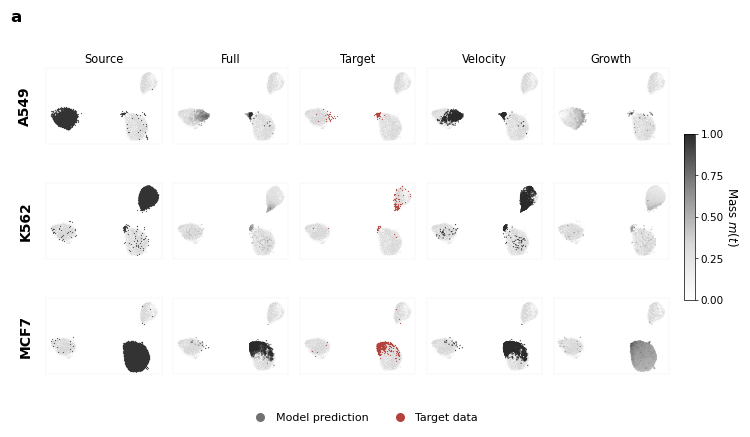

In [74]:
fig

In [58]:
ranked = sorted(
    [(k, v["all"]["m_pred"].mean()) for k, v in results_embedding.items()],
    key=lambda x: x[1]
)
print(ranked[:10])


[("('Belinostat (PXD101)', 'A549', 10000.0, 72.0)", np.float32(0.02644685)), ("('Dacinostat (LAQ824)', 'A549', 10000.0, 72.0)", np.float32(0.12811333)), ("('Quisinostat (JNJ-26481585) 2HCl', 'A549', 10000.0, 72.0)", np.float32(0.23304857)), ("('Belinostat (PXD101)', 'K562', 10000.0, 24.0)", np.float32(0.34239691)), ("('Dacinostat (LAQ824)', 'K562', 10000.0, 24.0)", np.float32(0.38573456)), ("('Givinostat (ITF2357)', 'K562', 10000.0, 24.0)", np.float32(0.3861017)), ("('Quisinostat (JNJ-26481585) 2HCl', 'K562', 10000.0, 24.0)", np.float32(0.4055813)), ("('Quisinostat (JNJ-26481585) 2HCl', 'A549', 10000.0, 24.0)", np.float32(0.43373874)), ("('Givinostat (ITF2357)', 'A549', 10000.0, 24.0)", np.float32(0.435541)), ("('Alvespimycin (17-DMAG) HCl', 'MCF7', 10000.0, 24.0)", np.float32(0.45242354))]


In [76]:
plt_save_path = "figures/Sciplex3"

In [22]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition

cond_name = "('Belinostat (PXD101)', 'A549', 10000.0, 24.0)"

adata_source_subset = adata_control[indices].copy()

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_source_subset,
    sample_rep=sample_rep,
    save_times=(0.0, 1.0),
    reducer=reducer,
    background="all_source",
    g_mode="all",
    point_size=10,
    show_ticks=False,
    title_prefix="Multi-time UMAP",
)
plt.savefig(f"{plt_save_path}/Multi-time UMAP_{cond_name}.pdf") 
plt.show()


xlim = axes[0, 0].get_xlim()
ylim = axes[0, 0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,
    reducer=reducer,
    sample_rep=sample_rep,
    
    adata_background=adata_source_subset,
    background="all_source",
    time_key=None,
    time_value=1.0,

    adata_control=adata_source_subset,          
    control_celltype_key="cell_line",
    
    point_color="crimson",
    point_size=10.0,
    show_ticks=False,
    
    xlim=xlim,
    ylim=ylim,
)
plt.savefig(f"{plt_save_path}/True_treated_{cond_name}.pdf") 
plt.show()


NameError: name 'indices' is not defined

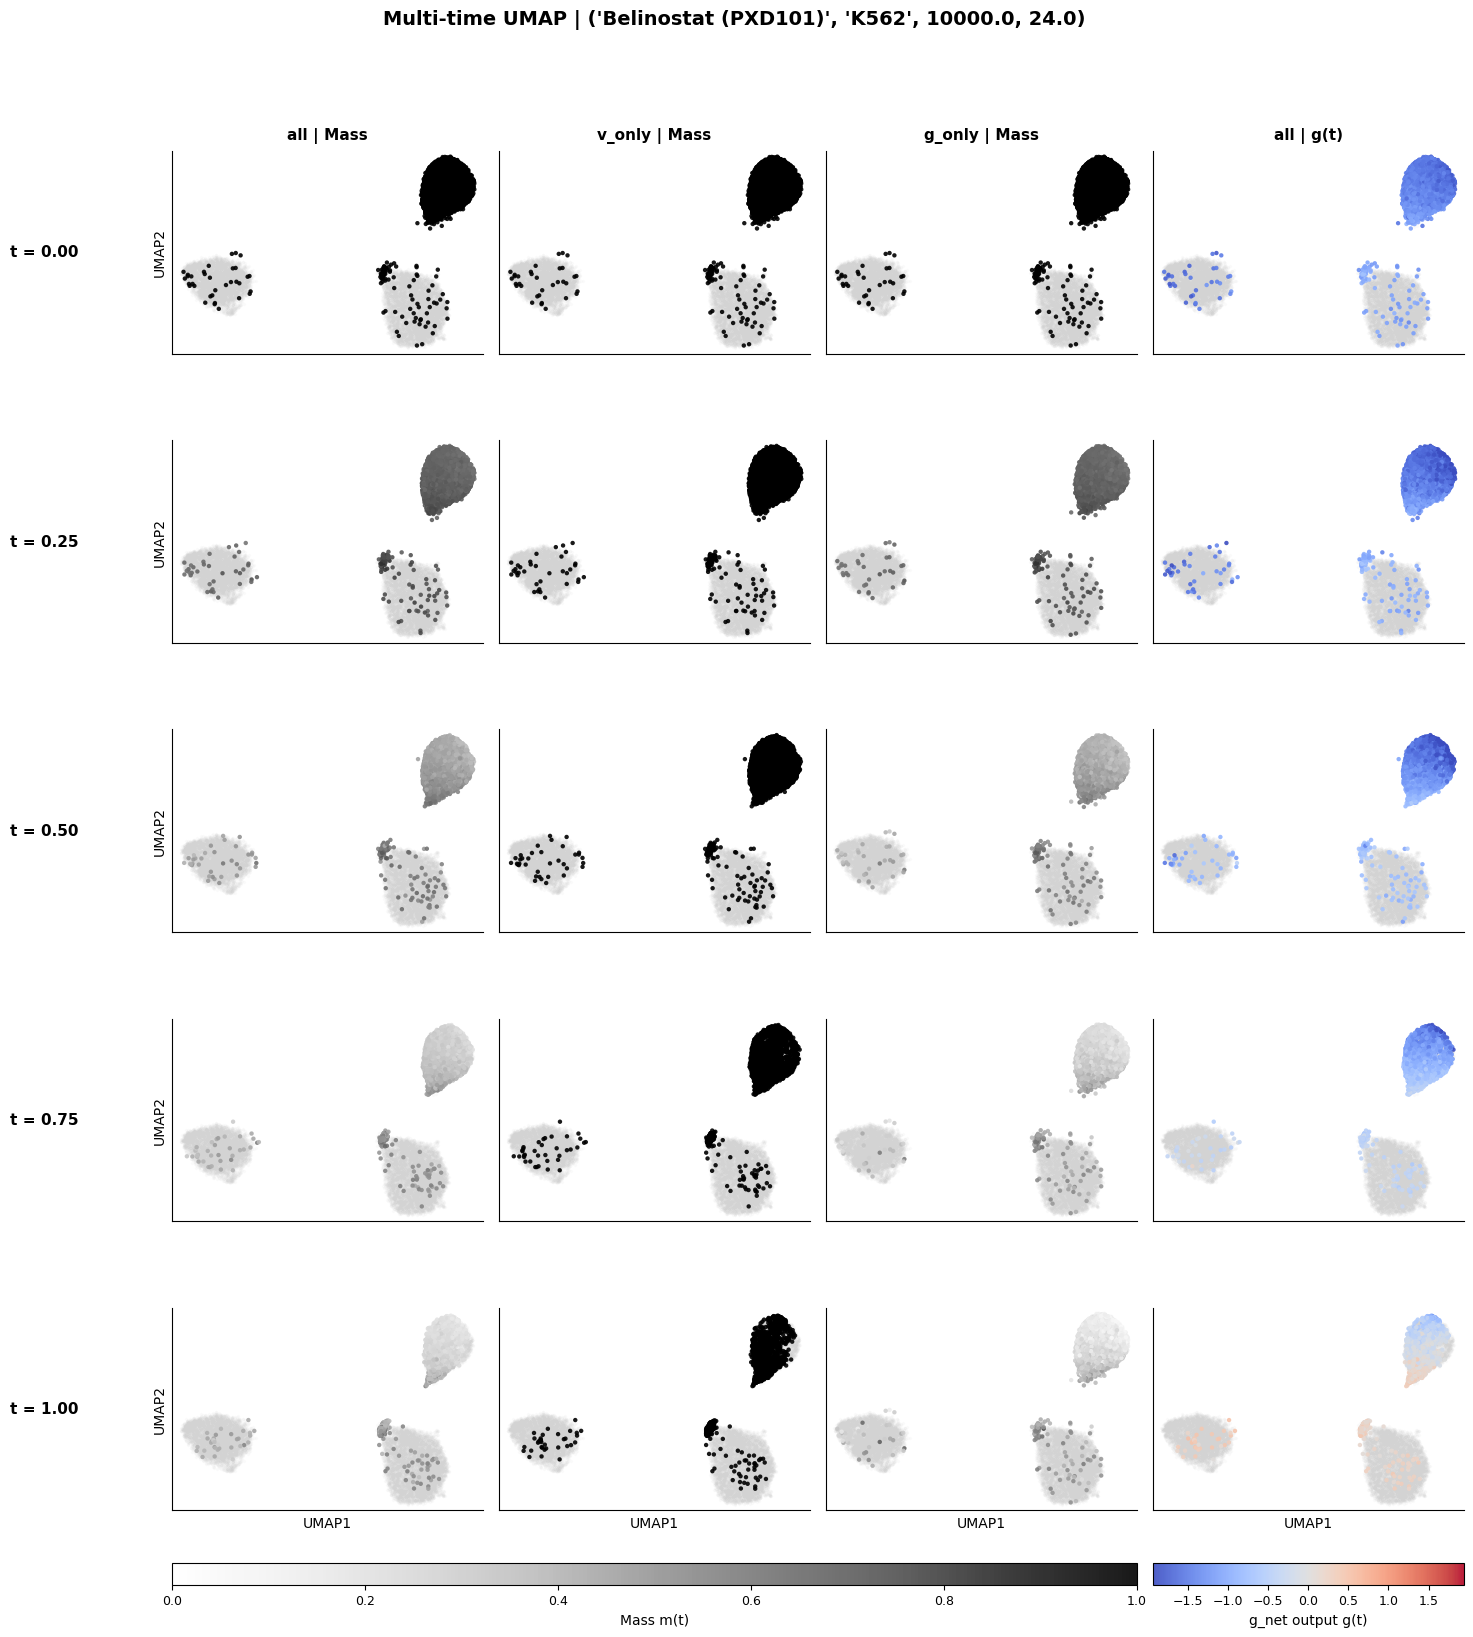

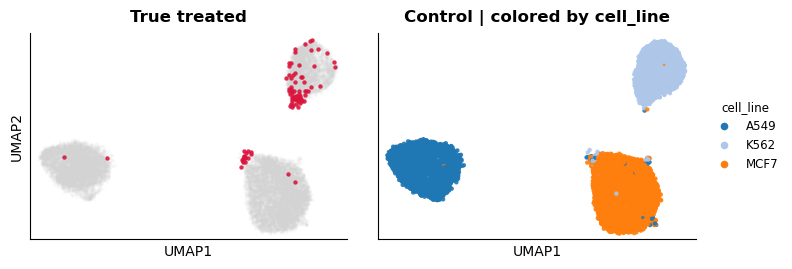

In [83]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition

cond_name = "('Belinostat (PXD101)', 'K562', 10000.0, 24.0)"

adata_source_subset = adata_control[indices].copy()

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_source_subset,
    sample_rep=sample_rep,
    save_times=(0.0, 0.25, 0.5, 0.75, 1.0),
    reducer=reducer,
    background="all_source",
    g_mode="all",
    point_size=10,
    show_ticks=False,
    title_prefix="Multi-time UMAP",
)
plt.savefig(f"{plt_save_path}/Multi-time UMAP_{cond_name}.pdf") 
plt.show()

xlim = axes[0, 0].get_xlim()
ylim = axes[0, 0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,
    reducer=reducer,
    sample_rep=sample_rep,
    
    adata_background=adata_source_subset,
    background="all_source",
    time_key=None,
    time_value=1.0,

    adata_control=adata_source_subset,          
    control_celltype_key="cell_line",
    
    point_color="crimson",
    point_size=10.0,
    show_ticks=False,
    
    xlim=xlim,
    ylim=ylim,
)
plt.savefig(f"{plt_save_path}/True_treated_{cond_name}.pdf") 
plt.show()


In [ ]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition

cond_name = "('Belinostat (PXD101)', 'MCF7', 10000.0, 24.0)"

adata_source_subset = adata_control[indices].copy()

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_source_subset,
    sample_rep=sample_rep,
    save_times=(0.0, 0.25, 0.5, 0.75, 1.0),
    reducer=reducer,
    background="all_source",
    g_mode="all",
    point_size=10,
    show_ticks=False,
    title_prefix="Multi-time UMAP",
)
plt.savefig(f"{plt_save_path}/Multi-time UMAP_{cond_name}.pdf") 
plt.show()

xlim = axes[0, 0].get_xlim()
ylim = axes[0, 0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,
    reducer=reducer,
    sample_rep=sample_rep,
    
    adata_background=adata_source_subset,
    background="all_source",
    time_key=None,
    time_value=1.0,

    adata_control=adata_source_subset,          
    control_celltype_key="cell_line",
    
    point_color="crimson",
    point_size=10.0,
    show_ticks=False,
    
    xlim=xlim,
    ylim=ylim,
)
plt.savefig(f"{plt_save_path}/True_treated_{cond_name}.pdf") 
plt.show()


## dose effect

In [18]:
from src.evaluate.wfr_multidose_helper import *

In [36]:
covariate_specs = {
     "dose_value": {
        #"values": [10, 30,50, 100,300,500, 1000,3000, 5000, 10000,30000,50000,100000]
        "start": 10, "end": 100000, "n": 13, "spacing": "log"
    }
}


results = run_dose_interpolation_inference(
    model=model,
    adata_control=adata_control,
    adata_test=adata_test,
    wishlist=wishlist,
    condition_keys=condition_keys,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device=device,
    covariate_specs=covariate_specs,
    n_particles=10000,
    random_seed=42,
    n_steps=50,
    inference_modes=("all",),
)


Base wishlist size: 12
Unique base wishlist size: 3
Expanded wishlist size: 39
Starting latent inference for 39 conditions...
Running inference for 39 conditions ...
Modes: ['all']
Latent inference completed.


In [37]:
particle_df = flatten_inference_results_to_particle_df(
    results,
    mode="all",
    particle_subsample=5000,
)

summary_df = summarize_particle_df(
    particle_df,
    x_key="dose_value",
)

true_df = add_true_mass_ratio_to_df(
    df=summary_df,
    adata_treated=adata_test,
    adata_control=adata_control,
    rulebook=rulebook,
    mass_deduct_key=mass_deduct_keys,
    x_key="dose_value",
    fixed_values={"time": 24.0},
)


In [40]:
from src.evaluate.wfr_multidose_helper import *
from src.evaluate.wfr_multidose_plot import plot_dose_violin_panel_nature_methods

/tmp/ipykernel_3354811/368472207.py:548: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(raw_density, y_grid)
/tmp/ipykernel_3354811/368472207.py:548: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(raw_density, y_grid)
/tmp/ipykernel_3354811/368472207.py:548: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(raw_density, y_grid)


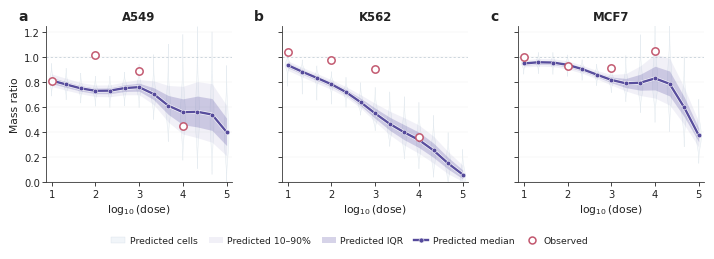

In [45]:
fig, axes = plot_dose_violin_panel_nature_methods_refined(
    particle_df=particle_df,
    true_df=true_df,
    x_key="dose_value",
    y_key="mass_ratio",
    true_y_key="true_mass_ratio",
    perturb_key="perturbation",
    cellline_key="cell_line",
    fixed_values={"perturbation": "Belinostat (PXD101)"},

    # Layout
    ncols=3,
    figsize=(7.20, 2.55),
    cellline_order=["A549", "K562", "MCF7"],

    # Axis / ticks
    logx=True,
    logy=False,
    x_tick_mode="log_integer",
    xlabel=r"$\log_{10}(\mathrm{dose})$",
    ylabel="Mass ratio",
    y_limits=(0.0, 1.25),

    # Violin
    show_violin=True,
    violin_scale="area",
    violin_width=0.24,
    max_violin_width_factor=0.72,
    min_points_per_violin=20,
    density_alpha=0.14,
    density_outline_alpha=0.22,
    density_outline_width=0.35,
    trim_quantile=(0.005, 0.995),

    # Ribbons
    show_outer_ribbon=True,
    outer_interval=(0.10, 0.90),
    outer_ribbon_alpha=0.14,

    show_inner_ribbon=True,
    inner_interval=(0.25, 0.75),
    inner_ribbon_alpha=0.26,

    # Predicted median points (refined)
    center="median",
    prediction_linewidth=1.70,
    prediction_marker_size=3.35,
    prediction_marker_edge_width=0.35,

    # Observed points (refined)
    observed_marker="o",
    observed_size=28,
    observed_linewidth=1.10,

    # Panel labels
    show_panel_labels=True,
    panel_label_fontsize=10.0,
    panel_label_weight="bold",
    panel_label_offset=(-0.15, 1.105),

    # Labels / legend
    title_prefix=None,
    panel_title_mode="cellline",
    show_legend=True,
    legend_loc="lower center",

    # Typography
    font_family=None,
    base_fontsize=7.2,
    axis_label_fontsize=7.8,
    title_fontsize=8.4,
    legend_fontsize=6.7,

    minor_x_ticks=False,
    show=True,
)

fig.savefig("figures/Sciplex3/dose_interpolation_belinostat_nature_methods_refined_points.pdf")

In [ ]:
fig.savefig(
    "dose_interpolation_belinostat_horizontal.pdf",
    bbox_inches="tight",
    transparent=True,
)

fig.savefig(
    "dose_interpolation_belinostat_horizontal.svg",
    bbox_inches="tight",
    transparent=True,
)

fig.savefig(
    "dose_interpolation_belinostat_horizontal.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)


In [117]:
mass_df = flatten_resampled_inference_results_to_df(
    resampled_results,
    mode="all",
    perturb_key="perturbation",
    cellline_key="cell_line",
    dose_key="dose_value",
    time_key="time",
    mass_summary="mean",
)


In [118]:
summary_df = summarize_resampled_mass_ratio_quantiles(
    mass_df,
    x_key="dose_value",
    y_key="mass_ratio",
    perturb_key="perturbation",
    cellline_key="cell_line",
    fixed_values={
        "time": 24,
    },
    q_low=0.10,
    q_high=0.90,
)


In [119]:
true_df = add_true_mass_ratio_to_df_groupwise_control(
    df=summary_df,
    adata_treated=adata_test,
    adata_control=adata_control,
    rulebook=adata_control.uns['global_rulebook'],
    x_key="dose_value",
    perturb_key="perturbation",
    cellline_key="cell_line",
    mass_deduct_keys=mass_deduct_keys,
    fixed_values={
         "time": 24.0,
    },
    true_col="true_mass_ratio",
    use_groupwise_control=True,
)


In [120]:
true_df

,perturbation,cell_line,dose_value,mass_ratio_median,mass_ratio_mean,mass_ratio_low,mass_ratio_high,mass_ratio_sd,n_repeats,n_points,q_low,q_high,time,true_mass_ratio,n_true_cells,n_ctrl_cells
0,Belinostat (PXD101),A549,10.0,0.813965,0.813971,0.813097,0.814702,0.000748,20,20,0.1,0.9,24.0,0.805725,190,3773
1,Belinostat (PXD101),A549,70.0,0.737777,0.737857,0.736941,0.738699,0.000886,20,20,0.1,0.9,24.0,NaN,0,3773
2,Belinostat (PXD101),A549,100.0,0.730600,0.730623,0.729480,0.731602,0.000919,20,20,0.1,0.9,24.0,1.013517,239,3773
3,Belinostat (PXD101),A549,700.0,0.761784,0.762018,0.760674,0.763590,0.001212,20,20,0.1,0.9,24.0,NaN,0,3773
4,Belinostat (PXD101),A549,1000.0,0.760967,0.760842,0.759384,0.762098,0.001109,20,20,0.1,0.9,24.0,0.886297,209,3773
5,Belinostat (PXD101),A549,7000.0,0.590615,0.590034,0.586559,0.592687,0.003034,20,20,0.1,0.9,24.0,NaN,0,3773
6,Belinostat (PXD101),A549,10000.0,0.574361,0.573871,0.569719,0.578152,0.004181,20,20,0.1,0.9,24.0,0.449510,106,3773
7,Belinostat (PXD101),A549,50000.0,0.545422,0.546160,0.540388,0.551747,0.004501,20,20,0.1,0.9,24.0,NaN,0,3773
8,Belinostat (PXD101),K562,10.0,0.932904,0.932779,0.931867,0.933803,0.000771,20,20,0.1,0.9,24.0,1.040915,256,3935
9,Belinostat (PXD101),K562,70.0,0.804881,0.804823,0.803678,0.805962,0.000909,20,20,0.1,0.9,24.0,NaN,0,3935


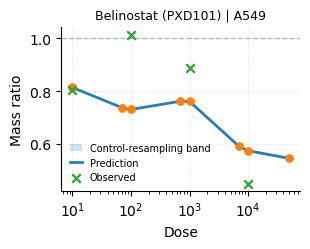

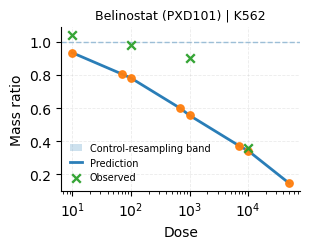

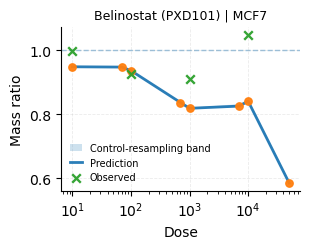

In [121]:
figs = plot_mass_ratio_quantile_band_by_x_single_cellline(
    summary_df=summary_df,
    x_key="dose_value",
    perturb_key="perturbation",
    cellline_key="cell_line",

    true_df=true_df,
    true_y_key="true_mass_ratio",

    y_center="mass_ratio_median",
    logx=True,
    logy=False,

    figsize=(3.2, 2.6),
    ylabel="Mass ratio",
    xlabel="Dose",
    show=True,
)


In [ ]:
for (pert, cellline), fig in figs.items():
    safe_pert = str(pert).replace("/", "_").replace(" ", "_")
    safe_cellline = str(cellline).replace("/", "_").replace(" ", "_")
    fig.savefig(
        f"mass_ratio_dose_response_{safe_pert}_{safe_cellline}.pdf",
        bbox_inches="tight",
        dpi=300,
    )


In [120]:
for cond,fig in fig_24.items():
    fig.savefig(f"{plt_save_path}/dose_interpolation24_{cond}.pdf", dpi=300, bbox_inches="tight")
for cond,fig in fig_72.items():
    fig.savefig(f"{plt_save_path}/dose_interpolation72_{cond}.pdf", dpi=300, bbox_inches="tight")

In [92]:
adata_test.obs[condition_combined_keys].value_counts()

condition_combined
('Givinostat (ITF2357)', 'MCF7', 10.0, 24.0)                  556
('Givinostat (ITF2357)', 'MCF7', 100.0, 24.0)                 548
('Belinostat (PXD101)', 'A549', 10.0, 72.0)                   516
('Belinostat (PXD101)', 'MCF7', 10000.0, 24.0)                510
('Quisinostat (JNJ-26481585) 2HCl', 'MCF7', 10000.0, 24.0)    492
                                                             ... 
('Flavopiridol HCl', 'MCF7', 10000.0, 24.0)                    27
('Quisinostat (JNJ-26481585) 2HCl', 'A549', 1000.0, 72.0)      26
('Alvespimycin (17-DMAG) HCl', 'MCF7', 10000.0, 24.0)          26
('Dacinostat (LAQ824)', 'A549', 10000.0, 72.0)                 22
('Quisinostat (JNJ-26481585) 2HCl', 'A549', 10000.0, 72.0)     14
Name: count, Length: 124, dtype: int64

In [93]:
adata_test.obs[mass_deduct_keys].value_counts()

plate_well
plate44_plate6_D1      343
plate43_plate5_D7      334
plate42_plate4_A2      313
plate44_plate6_D7      286
plate52_plate10_A2     284
                      ... 
plate21_plate7_F3       10
plate49_plate2_E2        8
plate52_plate10_E8       6
plate23_plate9_G4        5
plate32_plate10_G10      3
Name: count, Length: 248, dtype: int64

In [ ]:
with open(f"{results_save_path}_test", "wb") as f:
    artifacts = pickle.load(f)

In [ ]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]
adata_source = adata_control[indices]

In [ ]:
print(adata_test.obs["cell_type"].value_counts().to_string())

In [49]:
cell_line = "A549"

In [50]:
adata_control_cellline = adata_control[adata_control.obs["cell_line"]==cell_line].copy()

In [51]:
sc.tl.pca(adata_control, svd_solver='arpack')
sc.pp.neighbors(adata_control, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_control)

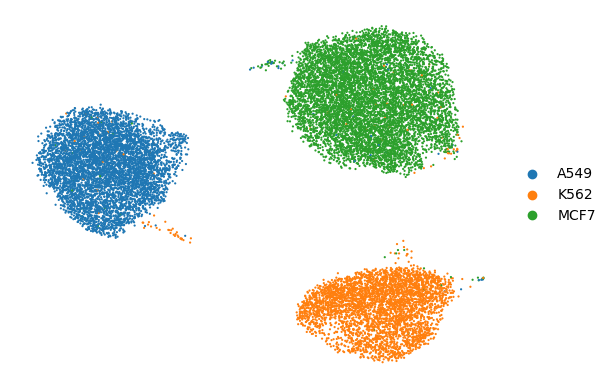

In [52]:
sc.pl.umap(
    adata_control, 
    color='cell_line',      # 按细胞类型着色
    frameon=False,          # 【关键】去掉周围的黑框和坐标轴
    title='',               # 去掉标题（方便后期AI排版）
    legend_fontsize=10,     # 标签字体大小
    size=10,                # 调整点的大小
    save='celltype.pdf'    # 保存为矢量图
)
# sc.pl.umap(
#     adata_control, 
#     vmin=0,
#     vmax=6,
#     color=[f'FCN1', f'IDO1'], 
# )

In [32]:
adata_test.obs["perturbation"].value_counts()

perturbation
Belinostat (PXD101)                4808
Dacinostat (LAQ824)                3609
Givinostat (ITF2357)               3545
Hesperadin                         3316
Quisinostat (JNJ-26481585) 2HCl    3025
TAK-901                            2559
Tanespimycin (17-AAG)              2488
Alvespimycin (17-DMAG) HCl         2089
Flavopiridol HCl                   1729
Name: count, dtype: int64

In [47]:
adata_true = adata_test[adata_test.obs["perturbation"]=="Flavopiridol HCl"].copy()
adata_true = adata_true[adata_true.obs["cell_line"]==cell_line].copy()
adata_pred = results_genes[f"('Flavopiridol HCl', {cell_line}, 10000.0, 24.0)"]

In [48]:
sc.tl.ingest(adata_true, adata_control, embedding_method='umap')
sc.tl.ingest(adata_pred, adata_control, embedding_method='umap')

/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [38]:
adata_control.obs['dataset'] = 'Control'
adata_true.obs['dataset'] = 'True'
adata_pred.obs['dataset'] = 'Pred'

/tmp/ipykernel_2744407/2058570734.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])


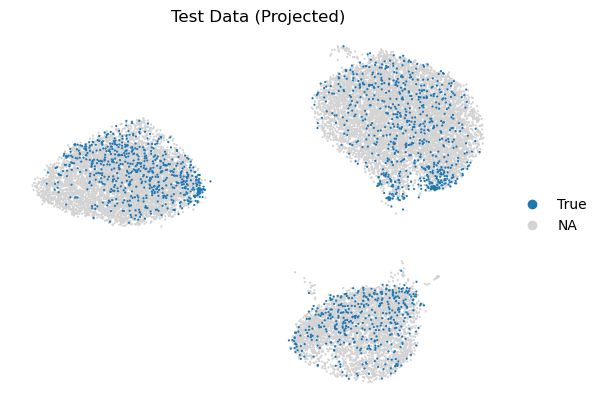

In [39]:
adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'True': '#1f77b4'} # 也可以用 hex 颜色码

# sc.pl.umap(
#     adata_all, 
#     color='plot_color', 
#     groups=['Control'], # 只高亮 Control
#     palette=color_map,
#     frameon=False,
#     title='Control',
#     size=10 # 根据细胞数调整点大小
# )

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['True'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Test Data (Projected)',
    size=10
)
# import numpy as np

# # 1. 复制一个用于绘图的对象，以免修改原数据
# adata_plot = adata_all.copy()

# # 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# # 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
# mask_control = adata_plot.obs['dataset'] == 'Control'

# # 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# # 这里演示最通用的方法：先把基因值存入 obs，再手动修改
# for gene in ['FCN1', 'IDO1']:
#     # 获取表达量 (处理稀疏矩阵的情况)
#     if hasattr(adata_plot.X, "toarray"):
#         values = adata_plot[:, gene].X.toarray().flatten()
#     else:
#         values = adata_plot[:, gene].X.flatten()
    
#     # 存入 obs
#     adata_plot.obs[f'plot_{gene}'] = values
    
#     # 将 Control 组的值设为 NaN
#     adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# # 3. 绘图
# sc.pl.umap(
#     adata_plot, 
#     color=[f'plot_FCN1', f'plot_IDO1'], 
#     na_color='lightgrey', # 这里设置背景色（Control的颜色）
#     na_in_legend=False,   # 图例中不显示 NaN
#     cmap='viridis',       # Pred 组的颜色映射
#     frameon=False,
#     vmin=0,
#     vmax=6,
#     size=10,
#     title=['FCN1 (True Only)', 'IDO1 (True Only)']
# )


/tmp/ipykernel_2744407/1497717609.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])


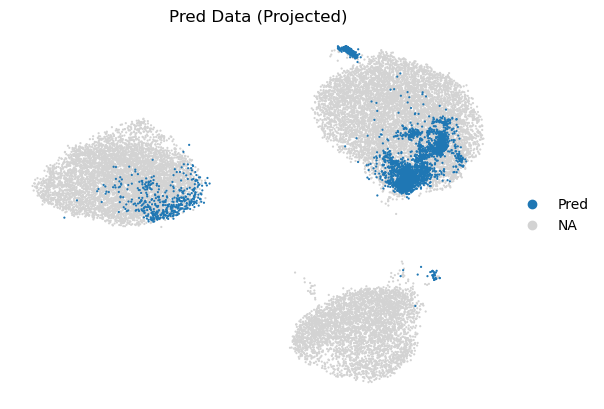

In [40]:
adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'Pred': '#1f77b4'} # 也可以用 hex 颜色码

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['Pred'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Pred Data (Projected)',
    size=10
)


# import numpy as np

# # 1. 复制一个用于绘图的对象，以免修改原数据
# adata_plot = adata_all.copy()

# # 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# # 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
# mask_control = adata_plot.obs['dataset'] == 'Control'

# # 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# # 这里演示最通用的方法：先把基因值存入 obs，再手动修改
# for gene in ['FCN1', 'IDO1']:
#     # 获取表达量 (处理稀疏矩阵的情况)
#     if hasattr(adata_plot.X, "toarray"):
#         values = adata_plot[:, gene].X.toarray().flatten()
#     else:
#         values = adata_plot[:, gene].X.flatten()
    
#     # 存入 obs
#     adata_plot.obs[f'plot_{gene}'] = values
    
#     # 将 Control 组的值设为 NaN
#     adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# # 3. 绘图
# sc.pl.umap(
#     adata_plot, 
#     color=[f'plot_FCN1', f'plot_IDO1'], 
#     na_color='lightgrey', # 这里设置背景色（Control的颜色）
#     na_in_legend=False,   # 图例中不显示 NaN
#     cmap='viridis',       # Pred 组的颜色映射
#     frameon=False,
#     vmin=0,
#     vmax=6,
#     size=10,
#     title=['FCN1 (Pred Only)', 'IDO1 (Pred Only)']
# )
# import numpy as np

# # 1. 复制一份用于绘图，避免污染原数据
# adata_plot = adata_all.copy()

# # 2. 初始化一个新的列用于绘图，先全部设为 NaN (灰色)
# adata_plot.obs['plot_mass'] = np.nan

# # 3. 找到 Pred 组的位置
# mask_pred = adata_plot.obs['dataset'] == 'Pred'

# # 4. 将 mass 的值填入 Pred 组对应的位置
# # .values 确保赋值时忽略索引名称差异（concat 可能会改索引名）
# adata_plot.obs.loc[mask_pred, 'plot_mass'] = adata_pred.obs['mass'].values

# # 5. 绘图
# sc.pl.umap(
#     adata_plot, 
#     color='plot_mass', 
#     na_color='lightgrey', # Control 组（NaN）显示的颜色
#     na_in_legend=False,   # 图例中不显示灰色
#     cmap='viridis',       # mass 的色阶
#     frameon=False,
#     size=10,
#     title='Mass on Projected Data'
# )

In [ ]:
adata_pred

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)